In [1]:
import pandas as pd

df = pd.read_csv("quadrant_predictions.csv")

In [2]:
df

,image_path,pred_area_cm2,gt_area_cm2,abs_error_cm2,rel_error_fraction
0,automated_underwater_area_estimation\data_prep...,0.000371,0.000362,0.000008,0.022104
1,automated_underwater_area_estimation\data_prep...,0.000321,0.000329,0.000007,0.022204
2,automated_underwater_area_estimation\data_prep...,0.000364,0.000398,0.000034,0.084931
3,automated_underwater_area_estimation\data_prep...,0.000368,0.000400,0.000032,0.081088
4,automated_underwater_area_estimation\data_prep...,0.000334,0.000352,0.000018,0.050022
5,automated_underwater_area_estimation\data_prep...,0.000478,0.000473,0.000004,0.009223
6,automated_underwater_area_estimation\data_prep...,0.000361,0.000367,0.000006,0.015521
7,automated_underwater_area_estimation\data_prep...,0.000330,0.000313,0.000016,0.052534
8,automated_underwater_area_estimation\data_prep...,0.000438,0.000469,0.000030,0.064917
9,automated_underwater_area_estimation\data_prep...,0.000403,0.000406,0.000003,0.008368


56/59 = 94.92% are within ±10%


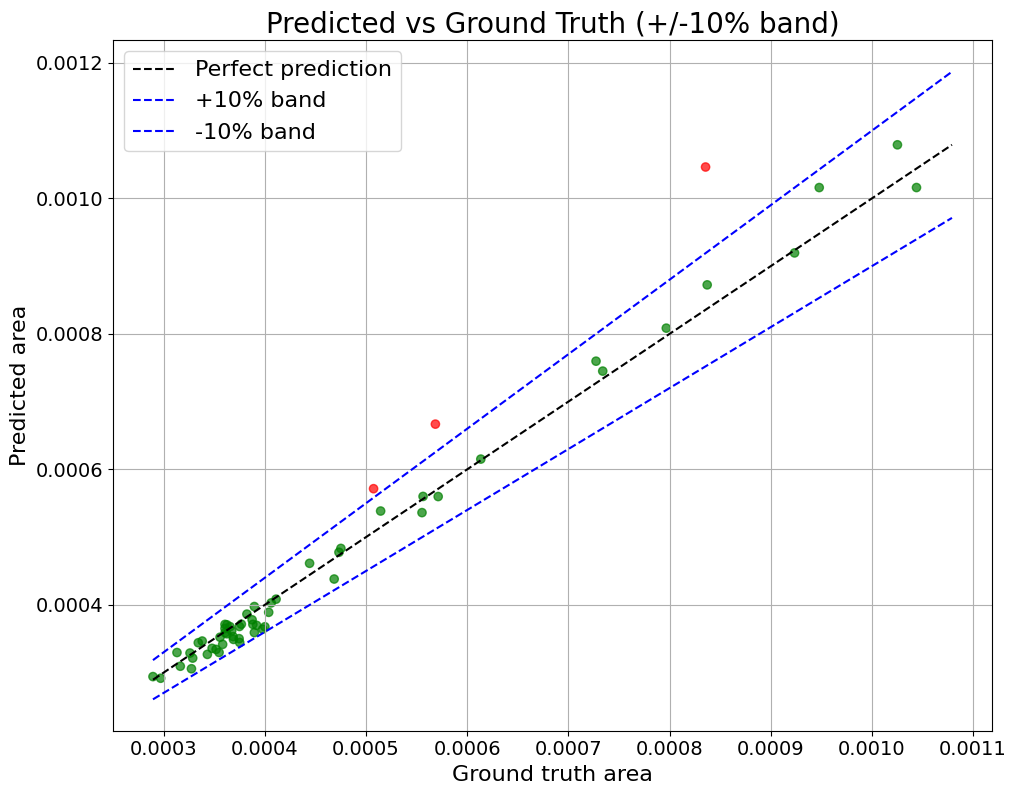

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')

# compute relative error if not given
df["rel_error"] = np.abs(df["pred_area_cm2"] - df["gt_area_cm2"]) / df["pred_area_cm2"]

# flag within 10%
threshold = 0.10
df["within10pct"] = df["rel_error"] <= threshold

# summary
n = len(df)
n_within = df["within10pct"].sum()

# scatter plot
fig1 = plt.figure(figsize=(10,8))
plt.scatter(df["gt_area_cm2"], df["pred_area_cm2"],
            c=df["within10pct"].map({True:"green", False:"red"}),
            alpha=0.7)
minv = min(df["gt_area_cm2"].min(), df["pred_area_cm2"].min())
maxv = max(df["gt_area_cm2"].max(), df["pred_area_cm2"].max())
plt.plot([minv, maxv], [minv, maxv], 'k--', label="Perfect prediction")
plt.plot([minv, maxv], [minv*(1+threshold), maxv*(1+threshold)], 'b--', label=f"+{threshold*100:.0f}% band")
plt.plot([minv, maxv], [minv*(1-threshold), maxv*(1-threshold)], 'b--', label=f"-{threshold*100:.0f}% band")
plt.xlabel("Ground truth area", fontsize=16)
plt.ylabel("Predicted area", fontsize=16)
plt.title("Predicted vs Ground Truth (+/-10% band)", fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=14)

# Save to file
fig1.savefig("scatter_pred_vs_gt.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig1)
